In [ ]:
import os
import pandas as pd

from app.config.settings import INTERIM_DATA_DIR

from dowhy import CausalModel

c:\Users\mazza\AppData\Local\pypoetry\Cache\virtualenvs\app-17oa4emR-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

print(df.shape)
df.head()

(97712, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,avg_width,total_payment,avg_payment,max_installments,n_payments_type,OSR,installment_value,purchase_hour,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,38.71,12.903333,1.0,3.0,1,38.710000,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,141.46,141.460000,1.0,1.0,1,141.460000,20,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,21.0,179.12,179.120000,3.0,1.0,1,59.706667,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,20.0,72.20,72.200000,1.0,1.0,1,72.200000,19,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,15.0,28.62,28.620000,1.0,1.0,1,28.620000,21,1,2


In [3]:
df['perc_freight'] = (df['total_freight'] / df['total_price'])

df["T"] = (df["perc_freight"] < 0.05).astype(int)

print(df.groupby("T")["OSR"].mean())
df["T"].value_counts(normalize=True)

T
0    0.987233
1    0.990509
Name: OSR, dtype: float64


T
0    0.957948
1    0.042052
Name: proportion, dtype: float64

In [4]:
common_causes = [
    "total_price",
    "n_items",
    "n_item_distinct_categ",
    "avg_weight",
    "avg_length",
    "avg_height",
    "avg_width",
    "customer_state",
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "n_items_missing_info"
]

In [5]:
df = df.dropna(subset=common_causes + ["T", "OSR"])

In [ ]:
# O DoWhy assume que já foi feita a separação de mediators, colliders, post_treatment

In [7]:
causal_graph = """
digraph {
    T -> OSR;

    total_price -> T;
    total_price -> OSR;

    n_items -> T;
    n_items -> OSR;

    n_item_distinct_categ -> T;
    n_item_distinct_categ -> OSR;

    avg_weight -> T;
    avg_weight -> OSR;

    avg_length -> T;
    avg_length -> OSR;

    avg_height -> T;
    avg_height -> OSR;

    avg_width -> T;
    avg_width -> OSR;

    customer_state -> T;
    customer_state -> OSR;

    purchase_month -> T;
    purchase_month -> OSR;

    purchase_weekday -> T;
    purchase_weekday -> OSR;

    purchase_hour -> T;
    purchase_hour -> OSR;

    n_items_missing_info -> T;
    n_items_missing_info -> OSR;
}
"""

In [8]:
# explicitar o DAG:

model = CausalModel(
    data = df[common_causes + ["T", "OSR"]],
    treatment = "T",
    outcome = "OSR",
    graph=causal_graph
)

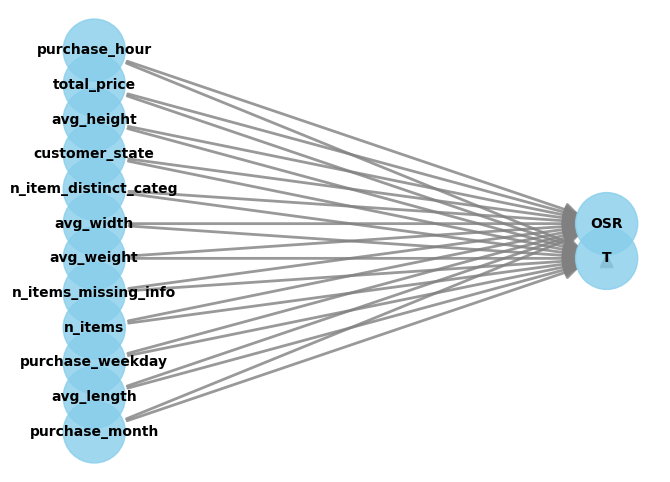

In [18]:
g = model.view_model()

In [10]:
identified_estimand = model.identify_effect()

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                                                                             ↪
────(E[OSR|purchase_⟨month,⟩_length,purchase_weekday,n_items,n_items_missing_⟨ ↪
d[T]                                                                           ↪

↪                                                                              ↪
↪ info,⟩_⟨weight,⟩_width,n_item_distinct_categ,customer_⟨state,⟩_height,total_ ↪
↪                                                                              ↪

↪                      
↪ price,purchase_hour])
↪                      
Estimand assumption 1, Unconfoundedness: If U→{T} and U→OSR then P(OSR|T,purchase_month,avg_length,purchase_weekday,n_items,n_items_missing_info,avg_weight,avg_width,n_item_distinct_categ,customer_state,avg_height,total_price,purchase_hour,U) = P(OSR|T,purchase_month,avg_length,purchase_weekday,n_items,n_items_missing_info,avg_we

In [12]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name= "backdoor.propensity_score_weighting"
)

print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                                                                             ↪
────(E[OSR|purchase_⟨month,⟩_length,purchase_weekday,n_items,n_items_missing_⟨ ↪
d[T]                                                                           ↪

↪                                                                              ↪
↪ info,⟩_⟨weight,⟩_width,n_item_distinct_categ,customer_⟨state,⟩_height,total_ ↪
↪                                                                              ↪

↪                      
↪ price,purchase_hour])
↪                      
Estimand assumption 1, Unconfoundedness: If U→{T} and U→OSR then P(OSR|T,purchase_month,avg_length,purchase_weekday,n_items,n_items_missing_info,avg_weight,avg_width,n_item_distinct_categ,customer_state,avg_height,total_price,purchase_hour,U) = P(OSR|T,purchase_month,avg_length,purc

c:\Users\mazza\AppData\Local\pypoetry\Cache\virtualenvs\app-17oa4emR-py3.11\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter"
)

print(refute)

Refute: Use a Placebo Treatment
Estimated effect:-0.0021746819789397742
New effect:0.0022935194980265284
p value:0.0

